# How in Python: simulate, sweep, convolve, invert

Reproducing the [`Apps/RTMs`](https://github.com/CCGCAM/RTM-Suite/tree/main/Apps/RTMs) Shiny app's own workflow, step by step, in plain Python -- no app required. Six steps: load the package, run one simulation, run 500, look at sensitivity to one trait at a time, convolve onto a real sensor's bands, and invert sensor-band reflectance back into a trait with machine learning. Every code cell below runs in sequence -- later steps reuse variables from earlier ones, same as the app's own tutorial tab, and the same as the R version of this tutorial (`How-in-R.Rmd`, side by side).

Worked example throughout: **fourSAIL + PROSPECT-D**. Swap in any of `foursail2`/`inform` and `PROSPECT-PRO`/`Fluspect-B`/`Fluspect-B-Cx`/`Liberty` by changing step 1-2's model/parameter names -- see the app's own **Model Explorer** tab for an interactive version of every combination.

## 1. Load the package

In [1]:
import numpy as np
from toolsrtm import foursail, compute_brf

## 2. Run one simulation

Build a single-row parameter set (one plant/canopy's worth of trait values), run the canopy model, and combine its direct/diffuse-light outputs into one reflectance spectrum -- the most basic thing this whole pipeline does.

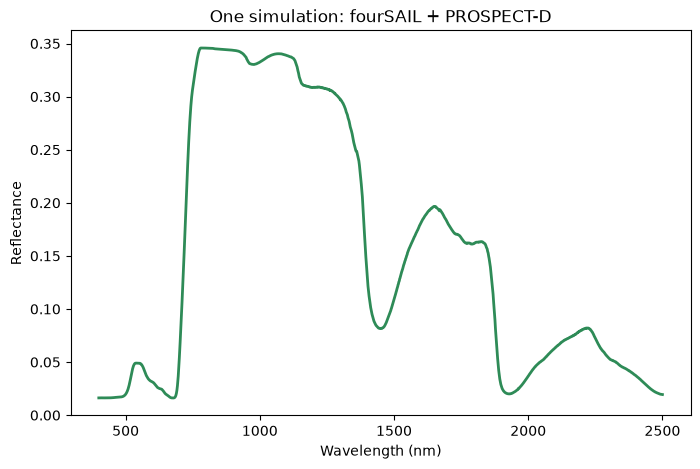

In [2]:
row = {
    "LAI": 3, "hspot": 0.01, "LIDFa": -0.35, "LIDFb": -0.15, "TypeLidf": 1,
    "tts": 30, "tto": 0, "psi": 0,
    "N": 1.5, "Cab": 40, "Car": 8, "Anth": 2, "Cbrown": 0, "EWT": 0.009, "LMA": 0.009, "alpha": 40,
}
wavelength = np.arange(400, 2501)
rsoil = np.full(2101, 0.15)  # flat soil (see toolsrtm.marmit/BSM for a modeled soil)

sail = foursail(row, rsoil, leaf_model="PROSPECT-D")
reflectance = compute_brf(sail.rdot, sail.rsot, row["tts"])

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(wavelength, reflectance, color="#2E8B57", linewidth=2)
plt.xlabel("Wavelength (nm)"); plt.ylabel("Reflectance")
plt.title("One simulation: fourSAIL + PROSPECT-D")
plt.show()

![](images/tutorial_1sim.png)

**A note on BRDF and TOC correction**: the `compute_brf()` call above blends a canopy's hemispherical-directional (`rdot`) and bi-directional (`rsot`) reflectance factors using the sun/view geometry (`tts`/`tto`/`psi`) -- this IS the BRDF correction: it's needed whenever illumination or viewing geometry isn't fixed nadir-sun-normalized (off-nadir sensors, multi-angle acquisitions, comparing images from different overpass times/dates), so the resulting top-of-canopy (TOC) reflectance is comparable across geometries rather than confounded by them. For a flat, purely Lambertian assumption you'd only need `rsot` itself; using the full BRDF blend is what real satellites -- and this pipeline -- actually do.

**If you're using a Fluspect leaf model** (`Fluspect-B`/`Fluspect-B-Cx` instead of `PROSPECT-D`), see the "Bonus: fluorescence (SIF)" section at the end of this notebook -- Fluspect also simulates sun-induced fluorescence, and what a sensor actually measures is reflectance PLUS that emitted fluorescence, not reflectance alone.

## 3. Many simulations (n_samples = 500)

Do step 2 five hundred times, with trait values sampled randomly instead of fixed at one baseline -- this builds a LUT (look-up table): one row of traits, one simulated spectrum, times 500. Everything from here on (sensitivity, ML inversion) works from this LUT.

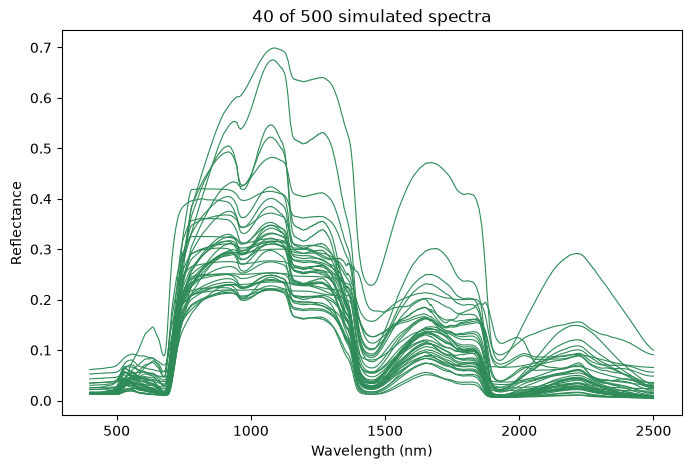

In [3]:
n_samples = 500
rng = np.random.default_rng(42)
lut = {
    "LAI": rng.uniform(0.5, 8, n_samples), "N": rng.uniform(1, 3, n_samples),
    "Cab": rng.uniform(0, 80, n_samples), "Car": rng.uniform(0, 20, n_samples),
    "Anth": rng.uniform(0, 7, n_samples), "Cbrown": rng.uniform(0, 1, n_samples),
    "EWT": rng.uniform(1e-04, 0.05, n_samples), "LMA": rng.uniform(1e-04, 0.03, n_samples),
    "hspot": 0.01, "LIDFa": -0.35, "LIDFb": -0.15, "TypeLidf": 1, "tts": 30, "tto": 0, "psi": 0,
    "alpha": 40,
}

spectra = np.empty((n_samples, 2101))
for i in range(n_samples):
    row_i = {k: (v[i] if hasattr(v, "__len__") else v) for k, v in lut.items()}
    sail_i = foursail(row_i, rsoil, leaf_model="PROSPECT-D")
    spectra[i] = compute_brf(sail_i.rdot, sail_i.rsot, row_i["tts"])

# A few random parameter draws can be numerically unstable for some leaf
# models (e.g. Liberty's inter-layer solver, near the edges of its own
# range) and come back as NaN -- drop those rows rather than propagating them.
ok = np.isfinite(spectra).all(axis=1)
spectra = spectra[ok]
lut = {k: (np.asarray(v)[ok] if hasattr(v, "__len__") else v) for k, v in lut.items()}

plt.figure(figsize=(8, 5))
plt.plot(wavelength, spectra[:40].T, color="#2E8B57", linewidth=0.8)
plt.xlabel("Wavelength (nm)"); plt.ylabel("Reflectance")
plt.title("40 of 500 simulated spectra")
plt.show()

![](images/tutorial_many_spectra.png)

## 4. Sensitivity: vary one trait at a time

Different question from step 3: instead of random combinations, hold every parameter at one fixed baseline except one, and sweep just that one trait across its realistic range -- this isolates which spectral regions respond to which trait (Cab: red/red-edge; LAI: NIR plateau; EWT: SWIR; Cbrown: visible/red-edge). The interactive equivalent is the app's own **Model Explorer > Sensitivity** sub-tab, which lets you pick the trait instead of it being fixed in code.

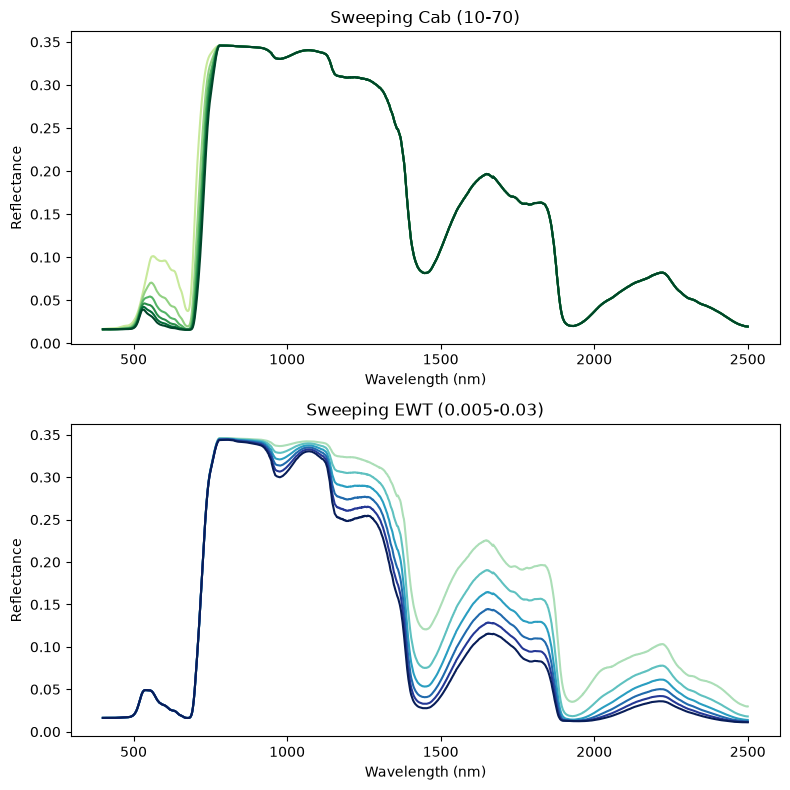

In [4]:
def sweep_trait(trait, values):
    curves = np.empty((len(values), len(wavelength)))
    for j, v in enumerate(values):
        row_j = dict(row); row_j[trait] = v
        sail_j = foursail(row_j, rsoil, leaf_model="PROSPECT-D")
        curves[j] = compute_brf(sail_j.rdot, sail_j.rsot, row_j["tts"])
    return curves

cab_curves = sweep_trait("Cab", np.linspace(10, 70, 6))
ewt_curves = sweep_trait("EWT", np.linspace(0.005, 0.03, 6))
# repeat for LAI, Cbrown, ... -- plot each trait in ITS OWN panel with its
# own color scale (a scale shared across traits hides every trait except
# the one with the largest absolute range).

fig, axes = plt.subplots(2, 1, figsize=(8, 8))
for curve, c in zip(cab_curves, plt.cm.YlGn(np.linspace(0.3, 1, 6))):
    axes[0].plot(wavelength, curve, color=c)
axes[0].set_title("Sweeping Cab (10-70)"); axes[0].set_xlabel("Wavelength (nm)"); axes[0].set_ylabel("Reflectance")
for curve, c in zip(ewt_curves, plt.cm.YlGnBu(np.linspace(0.3, 1, 6))):
    axes[1].plot(wavelength, curve, color=c)
axes[1].set_title("Sweeping EWT (0.005-0.03)"); axes[1].set_xlabel("Wavelength (nm)"); axes[1].set_ylabel("Reflectance")
plt.tight_layout(); plt.show()

![](images/tutorial_sensitivity.png)

## 5. Convolve to a specific sensor

Resample the native 1nm spectrum from step 2 onto a real sensor's bands (13 for Sentinel-2A here) using its spectral response function (SRF) -- this is what a satellite actually observes, coarser and fewer bands than the simulation itself.

**Three convolution functions, one for each kind of sensor data you might have:**

1. `spectral_convolution_srf()` (used below) -- a real, MEASURED per-nm SRF, no atmospheric-correction coefficients needed. Covers PRISMA and Sentinel-2A/Sentinel-2B (`srf_prisma()`/`srf_sentinel2a()`/`srf_sentinel2b()`).
2. `toolsrtm.smac.spectral_convolution()` -- a measured SRF bundled together WITH SMAC atmospheric-correction coefficients (only Sentinel-2A ships this way in the Python port so far; the other 5 SMAC-only sensors are R-only for now).
3. `spectral_convolution_gaussian()` -- no measured SRF at all, only NOMINAL band characteristics (center wavelength + FWHM, or center + published band edges), approximated as a Gaussian response. This is what you need for **EnMAP** (`sensor="EnMAP"`), for **ALI, Hyperion, MODIS (19-band nominal set), Quickbird, RapidEye, WorldView-2, Landsat** (`sensor="MODIS"`, etc.), and for **your own sensor or camera** -- pass your own `centers` (and, if you know it, `fwhm`) instead of `sensor`.

SrfConvolutionResult(band_names=['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B10', 'B11', 'B12'], wl=array([ 442.6950461 ,  492.71521346,  559.84905548,  664.62175292,
        704.11493622,  740.49182088,  782.75291733,  832.79041114,
        864.71078924,  945.05447044, 1373.45554874, 1613.68050304,
       2202.36780085]), fwhm=array([ 19.,  64.,  34.,  29.,  13.,  13.,  18., 104.,  19.,  18.,  29.,
        89., 173.]), rfl=array([0.01636016, 0.02190308, 0.04559242, 0.01747227, 0.07487495,
       0.28027331, 0.3453513 , 0.34507935, 0.34451222, 0.33779132,
       0.22433968, 0.18463209, 0.07317628]))


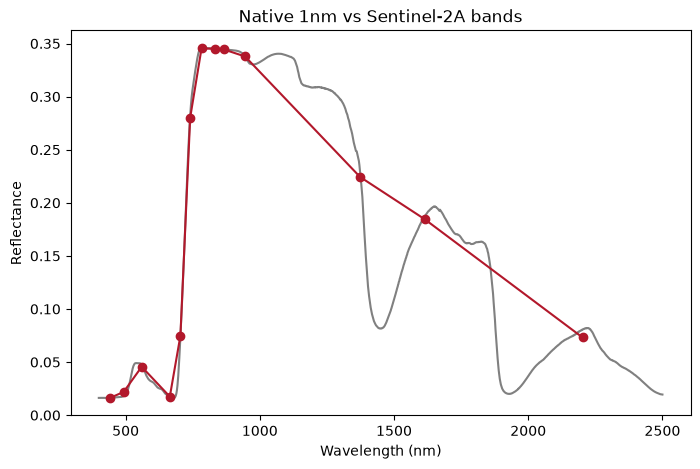

In [5]:
from toolsrtm.srf import srf_sentinel2a, spectral_convolution_srf

sensor = srf_sentinel2a()
band_values = spectral_convolution_srf(wavelength, reflectance, sensor)
# band_values.wl / .fwhm / .rfl / .band_names -- one entry per Sentinel-2A band, sorted by wavelength.
print(band_values)

plt.figure(figsize=(8, 5))
plt.plot(wavelength, reflectance, color="grey")
plt.scatter(band_values.wl, band_values.rfl, color="#B2182B", zorder=3)
plt.plot(band_values.wl, band_values.rfl, color="#B2182B", linewidth=1.5)
plt.xlabel("Wavelength (nm)"); plt.ylabel("Reflectance")
plt.title("Native 1nm vs Sentinel-2A bands")
plt.show()

![](images/tutorial_sensor_convolution.png)

### Worked example -- your own sensor

A synchronized 3-camera, 15-band rig with a known center + FWHM for every band (e.g. from a calibration sheet):

In [6]:
from toolsrtm.srf import spectral_convolution_gaussian

own_centers = [444, 475, 502, 531, 550, 560, 570, 650, 668, 678, 705, 717, 740, 754, 842]
own_fwhm    = [28,  32,  18,  14,  12,  27,  14,  16,  14,  14,  10,  12,  18,  10,  57]

own_bands = spectral_convolution_gaussian(wavelength, reflectance, centers=own_centers, fwhm=own_fwhm)
# No measured SRF for your camera -- each band is approximated as a
# Gaussian response with that center/FWHM.

# A pushbroom hyperspectral camera (e.g. Headwall) where only band centers
# are known (copied from its ENVI header's "wavelength = {...}" block, no
# "fwhm = {...}" block) -- FWHM is estimated from band spacing instead:
headwall_centers = [398.0166, 400.247, 402.4774, 404.7078, 406.9382]  # (full header has 272)
headwall_bands = spectral_convolution_gaussian(wavelength, reflectance, centers=headwall_centers)

# A bundled sensor with only nominal characteristics (no measured SRF):
enmap_bands = spectral_convolution_gaussian(wavelength, reflectance, sensor="EnMAP")
modis_bands = spectral_convolution_gaussian(wavelength, reflectance, sensor="MODIS")

own_bands

SrfConvolutionResult(band_names=['band1', 'band2', 'band3', 'band4', 'band5', 'band6', 'band7', 'band8', 'band9', 'band10', 'band11', 'band12', 'band13', 'band14', 'band15'], wl=array([444., 475., 502., 531., 550., 560., 570., 650., 668., 678., 705.,
       717., 740., 754., 842.]), fwhm=array([28., 32., 18., 14., 12., 27., 14., 16., 14., 14., 10., 12., 18.,
       10., 57.]), rfl=array([0.01641711, 0.01725667, 0.02164185, 0.04603846, 0.04871738,
       0.04546952, 0.04173278, 0.02005815, 0.01680514, 0.01680468,
       0.0794851 , 0.14775014, 0.27400382, 0.31481248, 0.34489865]))

## 6. Trait inversion with machine learning

The reverse problem from every step above: given ONLY the sensor-band reflectance (what a satellite actually measures), retrieve the trait (Cab here) that produced it, without knowing the ground truth. Train a model on step 3's LUT's (sensor-band reflectance -> trait) pairs, then evaluate it on held-out rows the model never saw during training.

R2: 0.8716949547013444  RMSE: 8.263295942783351


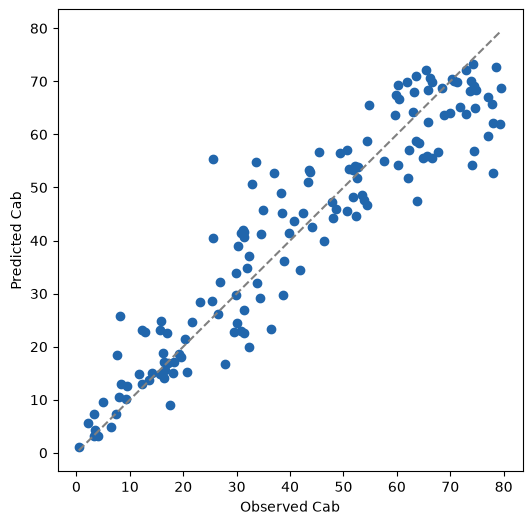

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

band_refl = np.array([spectral_convolution_srf(wavelength, spectra[i], sensor).rfl
                       for i in range(n_samples)])
X_train, X_test, y_train, y_test = train_test_split(
    band_refl, lut["Cab"], test_size=0.3, random_state=1)

rf = RandomForestRegressor(n_estimators=300, random_state=1)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print("R2:", r2_score(y_test, pred), " RMSE:", root_mean_squared_error(y_test, pred))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, color="#2166AC")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="grey", linestyle="--")
plt.xlabel("Observed Cab"); plt.ylabel("Predicted Cab")
plt.show()

![](images/tutorial_ml_inversion.png)

## Bonus: simulating fluorescence (SIF) with Fluspect

The steps above use PROSPECT-D, which has no fluorescence. Swap in `Fluspect-B`/`Fluspect-B-Cx` and every step still works the same way for reflectance -- but Fluspect also simulates sun-induced fluorescence (SIF), and what a sensor actually measures is reflectance PLUS that emitted fluorescence, not reflectance alone.

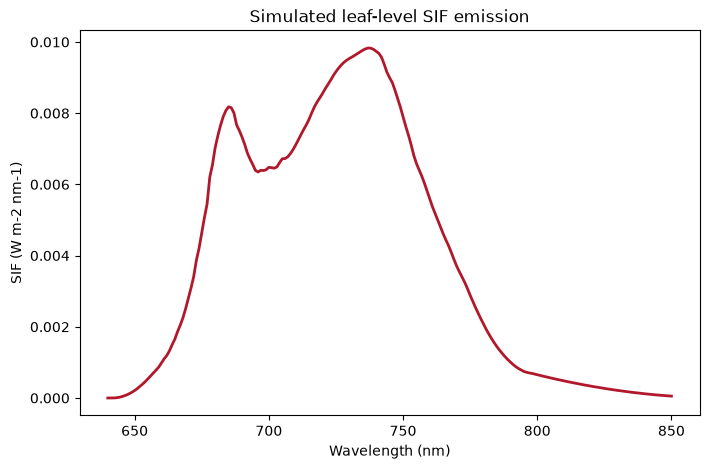

In [8]:
from toolsrtm import fluspect_b  # or fluspect_cx for Fluspect-B-Cx

wlE, wlF = np.arange(400, 751), np.arange(640, 851)
incident = np.full(len(wlE), 1.5)  # simplified flat placeholder irradiance (W m-2 nm-1) --
                                    # toolsrtm doesn't (yet) have a public helper for a real
                                    # (non-flat) spectrum here, see this tutorial's R version
                                    # (How-in-R.Rmd) for that, or compute_leaf_sif() in app.R.

lrt = fluspect_b(Cab=40, Car=10, EWT=0.015, LMA=0.01, Cs=0.1, N=1.8, fqe=0.01, Cx=0)
sif = (lrt.MbI + lrt.MbII) @ incident                       # simulated SIF emission, 640-850nm
refl_wlf = lrt.refl[(wlF[0] - 400):(wlF[-1] - 400 + 1)]      # true reflectance, same window
apparent_reflectance = refl_wlf + sif / incident[0]          # what a sensor actually measures

plt.figure(figsize=(8, 5))
plt.plot(wlF, sif, color="#B2182B", linewidth=2)
plt.xlabel("Wavelength (nm)"); plt.ylabel("SIF (W m-2 nm-1)")
plt.title("Simulated leaf-level SIF emission")
plt.show()

See the Model Explorer app's **SIF** sub-tab for a live, interactive version with a real (non-flat) incident irradiance spectrum.

## What changes on the app's other tabs

- **PROSAIL-WithSatellite**: steps 1 + 5 together, interactively, with the model fixed to fourSAIL + PROSPECT-PRO -- pick any bundled sensor from a dropdown instead of hardcoding Sentinel-2A.
- **Model Explorer**: step 1, generalized -- pick any of the 3 canopy models (fourSAIL/fourSAIL2/INFORM) and any of the 5 leaf models interactively, plus the interactive SIF, Sensitivity, and Absorption coefficients sub-tabs described above.

See [`CCGCAM/RTM-Suite`](https://github.com/CCGCAM/RTM-Suite) for the full course materials, the app itself, and the R/Python numerical verification writeup.